# Graph Analytics — RM Network (Industry × Sub-Industry × Region)
### Capstone Project: Screening Credit Agentic AI for eLO System

Notebook ini membangun **graph analytics level Relationship Manager (RM)**, dengan use case:
mendeteksi **RM yang portofolio nasabahnya saling tumpang tindih** (industry / sub_industry / region yang sama),
lalu mengukur **seberapa besar nilai (value)** dari tumpang tindih itu — baik dari sisi **kualitas risiko**
(`eligibility_score`) maupun dari sisi **nominal kredit yang disetujui**.

**Definisi graph:**
- **Node** = RM (`rm_id`), diperkaya atribut dari `rm_master.csv` (nama, cabang, region, jabatan, level)
  dan agregat portofolio dari `retail_customer_profile.csv` (jumlah nasabah, avg score, total kredit disetujui, dst).
- **Edge** antar dua RM terbentuk kalau portofolio nasabah mereka **beririsan** di kombinasi
  `industry` × `sub_industry` × `region` yang sama.
- **Value edge** (bobot) dihitung dua cara sekaligus — dua-duanya dipakai (bukan pilih salah satu):
  1. `avg_eligibility_score_shared` — rata-rata eligibility_score nasabah dari kedua RM yang berada
     di segmen (industry/sub_industry/region) yang sama-sama mereka pegang.
  2. `total_approved_credit_shared` — total nominal kredit **yang disetujui** (`loan_requested` dengan
     `label == 'Diterima'`) dari nasabah-nasabah di segmen yang sama itu.

**Alur (Tahap 0–8):**
0. Load & merge data (`retail_customer_profile.csv` + `rm_master.csv`)
1. Definisi kolom turunan (segmen komposit & kredit disetujui) + cek diversifikasi portofolio RM
2. Ringkasan portofolio per RM (node table)
3. Bipartite graph RM ↔ Segmen (industry|sub_industry|region)
4. Proyeksi ke graph RM–RM + hitung value edge (score & kredit disetujui)
5. Community detection (Louvain) — kelompok RM dengan portofolio mirip
6. Centrality — RM paling "sentral"/hub dalam jaringan
7. Visualisasi jaringan RM
8. Insight/narasi otomatis + export node & edge table


## Tahap 0 — Setup & Load Data

Sumber data:
- `retail_customer_profile.csv` — data aplikasi kredit nasabah, termasuk `rm_id`, `industry`, `sub_industry`,
  `region`, `eligibility_score`, `loan_requested`, `label` (Diterima/Ditolak).
- `rm_master.csv` — data master RM: `rm_id`, `rm_name`, `branch_name`, `region`, `jabatan`, `level`, `join_date`.

Kedua data digabung lewat `rm_id`.

In [1]:
import pandas as pd
import numpy as np
import itertools
import networkx as nx
from networkx.algorithms import bipartite

# --- Community detection: pakai networkx built-in (v3.0+), fallback ke python-louvain kalau ada ---
try:
    from networkx.algorithms.community import louvain_communities
    HAVE_NX_LOUVAIN = True
except ImportError:
    HAVE_NX_LOUVAIN = False

try:
    import community as community_louvain  # python-louvain, pip install python-louvain
    HAVE_PY_LOUVAIN = True
except ImportError:
    HAVE_PY_LOUVAIN = False

import matplotlib.pyplot as plt
import matplotlib.cm as cm

pd.set_option("display.max_columns", 50)
np.random.seed(42)

In [2]:
# ====== EDIT SESUAI FILE KAMU ======
CUSTOMER_PATH = "../data/raw/retail_customer_profile.csv"
RM_PATH = "../data/raw/rm_master.csv"

# ====== COLUMN MAPPING ======
COL = {
    "cust_id": "NIK",
    "rm_id": "rm_id",
    "industry": "industry",
    "sub_industry": "sub_industry",
    "region": "region",
    "score": "eligibility_score",
    "loan_requested": "loan_requested",
    "label": "label",
}

customers = pd.read_csv(CUSTOMER_PATH)
rm_master = pd.read_csv(RM_PATH)

print("retail_customer_profile:", customers.shape)
print("rm_master:", rm_master.shape)

df = customers.merge(rm_master, on=COL["rm_id"], how="left", suffixes=("", "_rm"))
print("Merged shape:", df.shape)

missing_rm = df[COL["rm_id"]].isna().sum()
unmatched_rm = df["rm_name"].isna().sum() if "rm_name" in df.columns else None
print("Nasabah tanpa rm_id:", missing_rm)
print("Nasabah dengan rm_id tapi tidak ketemu di rm_master:", unmatched_rm)

df.head(3)

retail_customer_profile: (3000, 41)
rm_master: (261, 8)
Merged shape: (3000, 48)
Nasabah tanpa rm_id: 0
Nasabah dengan rm_id tapi tidak ketemu di rm_master: 0


,application_id,NIK,cif_number,application_date,customer_type,company_name,legal_entity,owner_name,owner_gender,owner_age,owner_marital_status,owner_education,province,city,district,region,branch_name,industry,sub_industry,business_age_year,employee_count,monthly_turnover_est,transaction_frequency_monthly,loan_requested,jenis_kredit_diajukan,tenor_diajukan_bulan,tujuan_penggunaan_kredit,collateral_type,collateral_location,collateral_province,collateral_city,collateral_size_m2,collateral_market_value,collateral_liquidation_value,collateral_ratio,certificate_type,ownership_match,estimated_dsr,eligibility_score,label,rm_id,rm_name,branch_name_rm,region_rm,jabatan,level,kapasitas_max_nasabah,join_date
0,APP202600001,3276010601750001,CIF1000001,2025-07-08,UMKM,UD Santoso Abadi,UD,Budi Panjaitan,L,51,Menikah,S2,Jawa Barat,Depok,Sukmajaya,Region 2,KCP Puri Indah,Manufaktur,Konveksi,14,9,2672137,66,300000000,KI,54,Pembelian mesin produksi tambahan usaha Konveksi,Rumah,"Poris Plawad, Tangerang",Banten,Tangerang,423.4,2328496000,1862796800,7.76,HGB,Ya,3.0,0.804,Diterima,RM0136,Joko Situmorang,KCP Puri Indah,Kantor Wilayah Jakarta BSD,Relationship Banking Officer,Senior RB,10,2018-10-01
1,APP202600002,3172010301920002,CIF1000002,2025-03-23,UMKM,PT Panjaitan Jaya,CV,Andi Hidayat,L,34,Cerai Hidup,S2,DKI Jakarta,Jakarta Utara,Kramat Jati,Region 1,KCP Jatinegara,Transportasi,Rental Kendaraan,1,3,1807917,39,75000000,KUR,24,Tambahan modal kerja usaha Rental Kendaraan,Rumah,"Pluit, Jakarta Utara",DKI Jakarta,Jakarta Utara,174.8,3724038000,2979230400,49.65,HGB,Ya,3.0,0.641,Diterima,RM0191,Dedi Siregar,KCP Jatinegara,Kantor Wilayah 15 (Jakarta Timur),Relationship Banking Officer,Junior RB,9,2022-10-01
2,APP202600003,3671010604800003,CIF1000003,2025-08-20,UMKM,CV Hutapea Mandiri,PT,Doni Pratama,L,46,Cerai Hidup,S1,Banten,Tangerang,Bekasi Timur,Region 4,KCP Depok Beji,Manufaktur,Pengolahan Makanan Ringan,17,33,1698736,59,150000000,KUR,24,Tambahan modal kerja usaha Pengolahan Makanan ...,Tanah,"Sukabumi Selatan, Jakarta Barat",DKI Jakarta,Jakarta Barat,67.0,1681700000,1345360000,11.21,HGB,Ya,3.0,0.459,Ditolak,RM0257,Anton Tanjung,KCP Depok Beji,Kantor Wilayah 15 (Jakarta Timur),Relationship Banking Officer,Senior RB,19,2016-12-24


## Tahap 1 — Definisi Kolom Turunan

- `approved_credit` — nominal kredit yang **benar-benar disetujui**: `loan_requested` kalau `label == 'Diterima'`, else 0.
- `segment` — segmen komposit `industry|sub_industry|region` per nasabah. Ini yang jadi "jembatan" penghubung antar RM:
  dua RM terhubung kalau sama-sama punya nasabah di segmen yang sama.

In [3]:
df["approved_credit"] = np.where(
    df[COL["label"]].astype(str).str.strip().eq("Diterima"),
    df[COL["loan_requested"]],
    0.0,
)

df["segment"] = (
    df[COL["industry"]].astype(str) + "|" +
    df[COL["sub_industry"]].astype(str) + "|" +
    df[COL["region"]].astype(str)
)

df[COL["rm_id"]] = df[COL["rm_id"]].astype(str)
df = df.dropna(subset=[COL["rm_id"], COL["industry"], COL["sub_industry"], COL["region"]]).copy()

print("Jumlah RM unik (dari data nasabah):", df[COL["rm_id"]].nunique())
print("Jumlah RM di rm_master:", rm_master[COL["rm_id"]].nunique())
print("Jumlah segmen komposit unik:", df["segment"].nunique())
print("\nApproval rate keseluruhan: {:.1%}".format((df[COL["label"]] == "Diterima").mean()))
print("Total approved_credit: Rp {:,.0f}".format(df["approved_credit"].sum()))

df[[COL["rm_id"], COL["industry"], COL["sub_industry"], COL["region"], "segment", COL["score"],
    COL["loan_requested"], COL["label"], "approved_credit"]].head()

Jumlah RM unik (dari data nasabah): 261
Jumlah RM di rm_master: 261
Jumlah segmen komposit unik: 80

Approval rate keseluruhan: 84.9%
Total approved_credit: Rp 861,650,000,000


,rm_id,industry,sub_industry,region,segment,eligibility_score,loan_requested,label,approved_credit
0,RM0136,Manufaktur,Konveksi,Region 2,Manufaktur|Konveksi|Region 2,0.804,300000000,Diterima,300000000.0
1,RM0191,Transportasi,Rental Kendaraan,Region 1,Transportasi|Rental Kendaraan|Region 1,0.641,75000000,Diterima,75000000.0
2,RM0257,Manufaktur,Pengolahan Makanan Ringan,Region 4,Manufaktur|Pengolahan Makanan Ringan|Region 4,0.459,150000000,Ditolak,0.0
3,RM0248,Transportasi,Rental Kendaraan,Region 3,Transportasi|Rental Kendaraan|Region 3,0.641,200000000,Diterima,200000000.0
4,RM0151,Manufaktur,Furniture,Region 4,Manufaktur|Furniture|Region 4,0.688,750000000,Diterima,750000000.0


### Tahap 1b — Cek Diversifikasi Portofolio per RM

Sebelum membangun graph, cek dulu seberapa terkonsentrasi/tersebar portofolio tiap RM di kombinasi
industry/sub_industry/region. Kalau tiap RM ternyata menggarap **hampir semua** kategori (bukan fokus
di beberapa industry/region tertentu), graph RM–RM yang dibangun di Tahap 3–4 wajar akan **padat**
(banyak RM saling terhubung), karena hampir semua pasangan RM otomatis beririsan di suatu segmen.

In [4]:
n_industry_total = df[COL["industry"]].nunique()
n_region_total = df[COL["region"]].nunique()

div_check = df.groupby(COL["rm_id"]).agg(
    n_industry=(COL["industry"], "nunique"),
    n_region=(COL["region"], "nunique"),
)
avg_industry_cov = div_check["n_industry"].mean() / n_industry_total
avg_region_cov = div_check["n_region"].mean() / n_region_total

print(f"Total industry berbeda di data: {n_industry_total}, total region: {n_region_total}")
print(f"Rata-rata RM menggarap {div_check['n_industry'].mean():.1f}/{n_industry_total} industry "
      f"({avg_industry_cov:.0%}) dan {div_check['n_region'].mean():.1f}/{n_region_total} region "
      f"({avg_region_cov:.0%}) berbeda.")

if avg_industry_cov > 0.7 and avg_region_cov > 0.7:
    print("\n-> Portofolio RM terdiversifikasi merata (tidak fokus ke industry/region tertentu). "
          "Graph RM-RM di Tahap 4 diperkirakan padat (near-complete) — ini wajar, bukan bug. "
          "Untuk community detection, dipakai bobot yang dinormalisasi (Jaccard, Tahap 5) supaya "
          "struktur yang lebih halus tetap bisa terlihat.")
else:
    print("\n-> Ada indikasi spesialisasi RM ke industry/region tertentu. Graph RM-RM di Tahap 4 "
          "diperkirakan lebih sparse/tersegmentasi mengikuti spesialisasi tsb.")

Total industry berbeda di data: 6, total region: 4
Rata-rata RM menggarap 5.0/6 industry (83%) dan 3.7/4 region (92%) berbeda.

-> Portofolio RM terdiversifikasi merata (tidak fokus ke industry/region tertentu). Graph RM-RM di Tahap 4 diperkirakan padat (near-complete) — ini wajar, bukan bug. Untuk community detection, dipakai bobot yang dinormalisasi (Jaccard, Tahap 5) supaya struktur yang lebih halus tetap bisa terlihat.


## Tahap 2 — Ringkasan Portofolio per RM (Node Table)

Setiap RM diringkas jadi satu baris: jumlah nasabah, rata-rata eligibility_score, total & rata-rata
kredit disetujui, approval rate, serta segmen (industry/sub_industry/region) yang dominan di portofolionya.
Ini jadi tabel **node** untuk graph, dan juga output analitik berdiri sendiri yang berguna.

In [5]:
def top_value(s):
    return s.value_counts().idxmax() if len(s) else np.nan

rm_portfolio = df.groupby(COL["rm_id"]).agg(
    n_nasabah=(COL["cust_id"], "count"),
    n_diterima=(COL["label"], lambda s: (s == "Diterima").sum()),
    avg_eligibility_score=(COL["score"], "mean"),
    std_eligibility_score=(COL["score"], "std"),
    total_loan_requested=(COL["loan_requested"], "sum"),
    total_approved_credit=("approved_credit", "sum"),
    dominant_industry=(COL["industry"], top_value),
    dominant_sub_industry=(COL["sub_industry"], top_value),
    dominant_region=(COL["region"], top_value),
    n_industry=(COL["industry"], "nunique"),
    n_sub_industry=(COL["sub_industry"], "nunique"),
    n_region=(COL["region"], "nunique"),
).reset_index()

rm_portfolio["approval_rate"] = rm_portfolio["n_diterima"] / rm_portfolio["n_nasabah"]

rm_nodes = rm_portfolio.merge(rm_master, on=COL["rm_id"], how="left")

# beberapa rm_name bisa kebetulan sama (nama hasil generator data) -> beri label unik untuk viz/insight
dup_names = rm_nodes["rm_name"].duplicated(keep=False)
rm_nodes["rm_label"] = np.where(
    dup_names, rm_nodes["rm_name"] + " (" + rm_nodes[COL["rm_id"]] + ")", rm_nodes["rm_name"]
)
if dup_names.any():
    print("Perhatian: ada rm_name kembar (kebetulan dari data generator), dibedakan pakai rm_id di label:")
    print(rm_nodes.loc[dup_names, [COL["rm_id"], "rm_name"]].sort_values("rm_name"))

print("Jumlah RM (node):", len(rm_nodes))
rm_nodes.sort_values("total_approved_credit", ascending=False).head(10)[[
    COL["rm_id"], "rm_name", "region", "n_nasabah", "avg_eligibility_score",
    "approval_rate", "total_approved_credit", "dominant_sub_industry", "dominant_region",
]]

Perhatian: ada rm_name kembar (kebetulan dari data generator), dibedakan pakai rm_id di label:


      rm_id           rm_name
97   RM0098      Agus Hidayat
21   RM0022      Agus Hidayat
36   RM0037      Andi Suryadi
34   RM0035      Andi Suryadi
176  RM0177      Ani Setiawan
217  RM0218      Ani Setiawan
141  RM0142      Dedi Saputra
168  RM0169      Dedi Saputra
235  RM0236      Desi Santoso
161  RM0162      Desi Santoso
123  RM0124      Dewi Hutapea
115  RM0116      Dewi Hutapea
243  RM0244        Dian Halim
9    RM0010        Dian Halim
253  RM0254      Dian Pratama
26   RM0027      Dian Pratama
120  RM0121      Dian Suryadi
202  RM0203      Dian Suryadi
213  RM0214    Doni Panjaitan
186  RM0187    Doni Panjaitan
15   RM0016      Fauzi Rahman
207  RM0208      Fauzi Rahman
150  RM0151      Fauzi Wijaya
133  RM0134      Fauzi Wijaya
131  RM0132    Gunawan Wijaya
245  RM0246    Gunawan Wijaya
234  RM0235    Joko Panjaitan
149  RM0150    Joko Panjaitan
170  RM0171  Kartika Setiawan
231  RM0232  Kartika Setiawan
10   RM0011    Krisna Permana
103  RM0104    Krisna Permana
158  RM01

,rm_id,rm_name,region,n_nasabah,avg_eligibility_score,approval_rate,total_approved_credit,dominant_sub_industry,dominant_region
169,RM0170,Rian Suryadi,Kantor Wilayah Jakarta BSD,20,0.658350,0.950000,9.550000e+09,Jasa Konstruksi Kecil,Region 1
48,RM0049,Dian Siregar,Kantor Wilayah Jakarta Kemayoran,24,0.680417,0.875000,8.325000e+09,Pengolahan Makanan Ringan,Region 2
177,RM0178,Hendra Lubis,Kantor Wilayah 15 (Jakarta Timur),16,0.695187,1.000000,7.925000e+09,Ekspedisi Kecil,Region 3
168,RM0169,Dedi Saputra,Kantor Wilayah Jakarta BSD,15,0.726000,1.000000,7.675000e+09,Rental Kendaraan,Region 2
26,RM0027,Dian Pratama,Kantor Wilayah Jakarta Senayan,22,0.666864,0.818182,7.600000e+09,Toko Alat Tulis,Region 2
107,RM0108,Krisna Gunawan,Kantor Wilayah Jakarta Kemayoran,20,0.697200,0.850000,7.400000e+09,Toko Alat Tulis,Region 1
231,RM0232,Kartika Setiawan,Kantor Wilayah 15 (Jakarta Timur),18,0.708667,0.888889,7.250000e+09,Toko Alat Tulis,Region 4
21,RM0022,Agus Hidayat,Kantor Wilayah Jakarta Senayan,17,0.745235,1.000000,7.200000e+09,Distributor Hasil Tani,Region 1
202,RM0203,Dian Suryadi,Kantor Wilayah 15 (Jakarta Timur),22,0.729545,0.954545,7.175000e+09,Percetakan,Region 3
37,RM0038,Wulan Wibowo,Kantor Wilayah Jakarta Senayan,20,0.662200,0.850000,7.075000e+09,Rental Kendaraan,Region 2


## Tahap 3 — Bipartite Graph RM ↔ Segmen

Setiap RM dihubungkan ke node segmen (`industry|sub_industry|region`) untuk tiap nasabah yang mereka pegang.
Kalau dua RM sama-sama tersambung ke segmen yang sama, itu artinya portofolio mereka **beririsan** di
kombinasi industry/sub_industry/region tersebut.

In [6]:
B = nx.Graph()

rm_ids_in_data = df[COL["rm_id"]].unique().tolist()
segment_nodes = df["segment"].unique().tolist()

B.add_nodes_from(rm_ids_in_data, bipartite=0)
B.add_nodes_from(segment_nodes, bipartite=1)

# edge RM-segmen, weight = jumlah nasabah RM tsb di segmen itu
rm_seg_count = df.groupby([COL["rm_id"], "segment"]).size().reset_index(name="n")
for _, r in rm_seg_count.iterrows():
    B.add_edge(r[COL["rm_id"]], r["segment"], weight=r["n"])

print(f"Bipartite graph: {len(rm_ids_in_data)} RM, {len(segment_nodes)} segmen, {B.number_of_edges()} edge")
print("\nContoh segmen dengan paling banyak RM berbeda menggarapnya:")
seg_rm_count = rm_seg_count.groupby("segment")[COL["rm_id"]].nunique().sort_values(ascending=False)
print(seg_rm_count.head(10))

Bipartite graph: 261 RM, 80 segmen, 2772 edge

Contoh segmen dengan paling banyak RM berbeda menggarapnya:
segment
Transportasi|Ekspedisi Kecil|Region 1        65
Pertanian|Distributor Hasil Tani|Region 4    62
Pertanian|Peternakan Ayam|Region 4           60
Transportasi|Rental Kendaraan|Region 4       60
Transportasi|Ekspedisi Kecil|Region 3        58
Transportasi|Rental Kendaraan|Region 1       57
Pertanian|Peternakan Ayam|Region 2           57
Pertanian|Distributor Hasil Tani|Region 2    54
Transportasi|Ekspedisi Kecil|Region 4        53
Pertanian|Peternakan Ayam|Region 3           52
Name: rm_id, dtype: int64


## Tahap 4 — Proyeksi ke Graph RM–RM + Value Edge

Proyeksi bipartite RM↔segmen menghasilkan graph RM–RM: dua RM punya edge kalau berbagi **minimal satu
segmen** yang sama. Bobot topologi (`shared_segments`) = jumlah segmen komposit yang sama-sama mereka
garap. Selain itu, untuk tiap edge kita hitung juga **dua value langsung dari data mentah**
(bukan dari bobot proyeksi), dari gabungan nasabah kedua RM yang ada di segmen-segmen bersama itu:

- `avg_eligibility_score_shared`
- `total_approved_credit_shared`
- `n_customers_shared`

Ditambah tiga indikator irisan per-dimensi (bukan cuma komposit): `n_shared_industry`,
`n_shared_sub_industry`, `n_shared_region` — jumlah kategori industry/sub_industry/region masing-masing
yang sama-sama mereka garap (independen dari kombinasi tiga-tiganya sekaligus).

Terakhir dihitung juga `jaccard` = `shared_segments / (jumlah segmen unik gabungan kedua RM)` — versi
ternormalisasi dari `shared_segments` yang dipakai di Tahap 5, supaya RM dengan portofolio besar (banyak
segmen) tidak otomatis mendominasi hanya karena ukurannya, bukan karena kemiripannya.

In [7]:
rm_nodes_set = {n for n, d in B.nodes(data=True) if d["bipartite"] == 0}
G = bipartite.weighted_projected_graph(B, rm_nodes_set)
# weighted_projected_graph default weight = jumlah neighbor (segmen) bersama -> ganti nama biar jelas
for u, v, d in G.edges(data=True):
    d["shared_segments"] = d.pop("weight")

print(f"Graph RM-RM: {G.number_of_nodes()} node, {G.number_of_edges()} edge")

# --- pre-agregasi per (rm_id, segment) biar hitung value edge cepat ---
seg_agg = df.groupby([COL["rm_id"], "segment"]).agg(
    n=(COL["cust_id"], "count"),
    score_sum=(COL["score"], "sum"),
    credit_sum=("approved_credit", "sum"),
).to_dict(orient="index")

rm_segments = df.groupby(COL["rm_id"])["segment"].apply(set).to_dict()
rm_industries = df.groupby(COL["rm_id"])[COL["industry"]].apply(set).to_dict()
rm_sub_industries = df.groupby(COL["rm_id"])[COL["sub_industry"]].apply(set).to_dict()
rm_regions = df.groupby(COL["rm_id"])[COL["region"]].apply(set).to_dict()

for u, v, d in G.edges(data=True):
    shared_segs = rm_segments[u] & rm_segments[v]
    n_cust = score_sum = credit_sum = 0
    for seg in shared_segs:
        for rm in (u, v):
            agg = seg_agg.get((rm, seg))
            if agg:
                n_cust += agg["n"]
                score_sum += agg["score_sum"]
                credit_sum += agg["credit_sum"]
    d["n_customers_shared"] = n_cust
    d["avg_eligibility_score_shared"] = score_sum / n_cust if n_cust else np.nan
    d["total_approved_credit_shared"] = credit_sum
    d["n_shared_industry"] = len(rm_industries[u] & rm_industries[v])
    d["n_shared_sub_industry"] = len(rm_sub_industries[u] & rm_sub_industries[v])
    d["n_shared_region"] = len(rm_regions[u] & rm_regions[v])
    union_segs = len(rm_segments[u] | rm_segments[v])
    d["jaccard"] = d["shared_segments"] / union_segs if union_segs else 0.0

print(f"Densitas graph RM-RM: {nx.density(G):.2f} "
      "(1.0 = complete graph, semua pasangan RM terhubung)")

edges_df = nx.to_pandas_edgelist(G, source="rm_id_a", target="rm_id_b")
print("\nContoh edge dengan value:")
edges_df.sort_values("total_approved_credit_shared", ascending=False).head(10)

Graph RM-RM: 261 node, 26014 edge


Densitas graph RM-RM: 0.77 (1.0 = complete graph, semua pasangan RM terhubung)

Contoh edge dengan value:


,rm_id_a,rm_id_b,avg_eligibility_score_shared,n_shared_sub_industry,total_approved_credit_shared,n_customers_shared,n_shared_industry,jaccard,n_shared_region,shared_segments
3797,RM0169,RM0049,0.715000,7,8.550000e+09,19,5,0.307692,4,8
18317,RM0203,RM0178,0.710857,6,7.550000e+09,14,6,0.214286,4,6
3861,RM0169,RM0170,0.647727,6,7.450000e+09,11,5,0.185185,4,5
3914,RM0169,RM0176,0.703062,6,7.400000e+09,16,5,0.333333,4,7
3832,RM0169,RM0251,0.729308,6,7.400000e+09,13,5,0.260870,4,6
19290,RM0049,RM0055,0.670579,9,7.225000e+09,19,6,0.266667,4,8
21252,RM0216,RM0232,0.738167,8,6.950000e+09,12,5,0.206897,4,6
12645,RM0236,RM0203,0.741565,8,6.950000e+09,23,6,0.310345,4,9
3791,RM0169,RM0248,0.662437,5,6.950000e+09,16,5,0.318182,4,7
1138,RM0052,RM0046,0.692091,7,6.875000e+09,11,5,0.238095,3,5


## Tahap 5 — Community Detection (Louvain)

Community detection dijalankan di atas graph RM–RM dengan bobot **`jaccard`** (bukan `shared_segments`
mentah) — karena graph ini padat (lihat densitas di Tahap 4), bobot mentah membuat semua RM terlihat
"mirip" hanya karena portofolionya besar. Jaccard menormalisasi itu, sehingga cluster yang terbentuk
lebih mencerminkan **kemiripan relatif**, bukan cuma ukuran portofolio.

> Catatan: kalau hasil cluster di bawah ternyata tidak terlalu tajam bedanya (mis. komposisi
> region/sub_industry dominan mirip antar cluster), itu konsisten dengan temuan Tahap 1b — portofolio RM
> yang terdiversifikasi merata memang sulit dipisah jadi kelompok yang beda secara industry/region.

In [8]:
if HAVE_NX_LOUVAIN:
    communities = louvain_communities(G, weight="jaccard", seed=42)
elif HAVE_PY_LOUVAIN:
    partition = community_louvain.best_partition(G, weight="jaccard", random_state=42)
    communities_dict = {}
    for node, cid in partition.items():
        communities_dict.setdefault(cid, set()).add(node)
    communities = list(communities_dict.values())
else:
    raise ImportError("Butuh networkx>=3.0 (louvain_communities) atau package 'python-louvain'.")

print(f"Jumlah cluster RM terbentuk: {len(communities)}")

node_to_cluster = {}
for cid, nodes in enumerate(communities):
    for n in nodes:
        node_to_cluster[n] = cid

rm_nodes["cluster_id"] = rm_nodes[COL["rm_id"]].map(node_to_cluster)
rm_nodes["cluster_id"] = rm_nodes["cluster_id"].fillna(-1).astype(int)

cluster_summary = rm_nodes[rm_nodes["cluster_id"] != -1].groupby("cluster_id").agg(
    n_rm=(COL["rm_id"], "count"),
    total_nasabah=("n_nasabah", "sum"),
    avg_score=("avg_eligibility_score", "mean"),
    avg_approval_rate=("approval_rate", "mean"),
    total_approved_credit=("total_approved_credit", "sum"),
    dominant_region=("dominant_region", top_value),
    dominant_sub_industry=("dominant_sub_industry", top_value),
).sort_values("total_approved_credit", ascending=False)

cluster_summary

Jumlah cluster RM terbentuk: 4


,n_rm,total_nasabah,avg_score,avg_approval_rate,total_approved_credit,dominant_region,dominant_sub_industry
cluster_id,,,,,,,
1,71,892,0.675661,0.854379,2.474250e+11,Region 4,Ekspedisi Kecil
2,69,795,0.681012,0.852526,2.304750e+11,Region 3,Ekspedisi Kecil
0,67,730,0.668673,0.826273,2.096000e+11,Region 2,Distributor Hasil Tani
3,54,583,0.673870,0.846673,1.741500e+11,Region 4,Distributor Hasil Tani


## Tahap 6 — Centrality: RM Paling Sentral

Karena graph RM-RM padat (banyak RM terhubung ke hampir semua RM lain — lihat densitas Tahap 4),
*unweighted degree centrality* tidak informatif di sini (hampir semua RM akan bernilai ~1.0). Jadi dipakai
dua ukuran **berbobot** sebagai gantinya:
- **Jaccard strength** — total bobot `jaccard` dari semua edge yang menyentuh RM tsb, dinormalisasi.
  RM dengan nilai tinggi = portofolionya konsisten mirip dengan banyak RM lain (bukan sekadar besar).
- **Value centrality** — total `total_approved_credit_shared` dari semua edge yang menyentuh RM
  tsb, dipakai sebagai proxy **eksposur kredit** RM itu dalam jaringan konsentrasi segmen.

In [9]:
jaccard_strength = {n: 0.0 for n in G.nodes}
value_centrality = {n: 0.0 for n in G.nodes}
for u, v, d in G.edges(data=True):
    jaccard_strength[u] += d["jaccard"]
    jaccard_strength[v] += d["jaccard"]
    value_centrality[u] += d["total_approved_credit_shared"]
    value_centrality[v] += d["total_approved_credit_shared"]

n_minus_1 = G.number_of_nodes() - 1
rm_nodes["jaccard_strength"] = rm_nodes[COL["rm_id"]].map(
    {k: v / n_minus_1 for k, v in jaccard_strength.items()}
)
rm_nodes["value_centrality_credit"] = rm_nodes[COL["rm_id"]].map(value_centrality)

print("Top 10 RM — Jaccard strength (paling konsisten mirip dengan RM lain):")
display(rm_nodes.sort_values("jaccard_strength", ascending=False)
        .head(10)[[COL["rm_id"], "rm_name", "region", "jaccard_strength", "n_nasabah"]])

print("\nTop 10 RM — value centrality (eksposur kredit tertinggi di jaringan irisan segmen):")
display(rm_nodes.sort_values("value_centrality_credit", ascending=False)
        .head(10)[[COL["rm_id"], "rm_name", "region", "value_centrality_credit", "total_approved_credit"]])

Top 10 RM — Jaccard strength (paling konsisten mirip dengan RM lain):


,rm_id,rm_name,region,jaccard_strength,n_nasabah
202,RM0203,Dian Suryadi,Kantor Wilayah 15 (Jakarta Timur),0.113496,22
168,RM0169,Dedi Saputra,Kantor Wilayah Jakarta BSD,0.109037,15
99,RM0100,Agus Kurniawan,Kantor Wilayah Jakarta Kemayoran,0.108326,22
144,RM0145,Ratna Permana,Kantor Wilayah Jakarta BSD,0.106091,18
136,RM0137,Krisna Saputra,Kantor Wilayah Jakarta BSD,0.105578,22
133,RM0134,Fauzi Wijaya,Kantor Wilayah Jakarta BSD,0.104888,14
105,RM0106,Rina Siregar,Kantor Wilayah Jakarta Kemayoran,0.102907,22
45,RM0046,Sri Wijaya,Kantor Wilayah Jakarta Kemayoran,0.102722,16
37,RM0038,Wulan Wibowo,Kantor Wilayah Jakarta Senayan,0.101993,20
147,RM0148,Wati Situmorang,Kantor Wilayah Jakarta BSD,0.101630,11



Top 10 RM — value centrality (eksposur kredit tertinggi di jaringan irisan segmen):


,rm_id,rm_name,region,value_centrality_credit,total_approved_credit
202,RM0203,Dian Suryadi,Kantor Wilayah 15 (Jakarta Timur),5.569250e+11,7.175000e+09
168,RM0169,Dedi Saputra,Kantor Wilayah Jakarta BSD,5.238750e+11,7.675000e+09
169,RM0170,Rian Suryadi,Kantor Wilayah Jakarta BSD,5.238500e+11,9.550000e+09
177,RM0178,Hendra Lubis,Kantor Wilayah 15 (Jakarta Timur),5.210000e+11,7.925000e+09
37,RM0038,Wulan Wibowo,Kantor Wilayah Jakarta Senayan,4.977000e+11,7.075000e+09
48,RM0049,Dian Siregar,Kantor Wilayah Jakarta Kemayoran,4.915750e+11,8.325000e+09
105,RM0106,Rina Siregar,Kantor Wilayah Jakarta Kemayoran,4.795000e+11,7.025000e+09
107,RM0108,Krisna Gunawan,Kantor Wilayah Jakarta Kemayoran,4.443500e+11,7.400000e+09
51,RM0052,Novi Setiawan,Kantor Wilayah Jakarta Kemayoran,4.388500e+11,5.850000e+09
26,RM0027,Dian Pratama,Kantor Wilayah Jakarta Senayan,4.378500e+11,7.600000e+09


## Tahap 7 — Visualisasi Jaringan RM

Karena tiap RM biasanya beririsan dengan banyak RM lain (region cuma ada segelintir), graph lengkap bisa
padat. Untuk keterbacaan, layout utama memakai **semua RM sebagai node**, tapi edge yang digambar
dibatasi ke edge dengan value di atas ambang (kuartil atas), sementara ukuran & warna node tetap
merepresentasikan seluruh portofolio RM.

- **Node size** = total nasabah RM
- **Node color** = rata-rata eligibility_score RM (merah = rendah, hijau = tinggi)
- **Edge width** = `shared_segments` (topologi)
- **Edge color** = `total_approved_credit_shared` (value kredit disetujui dari irisan segmen)

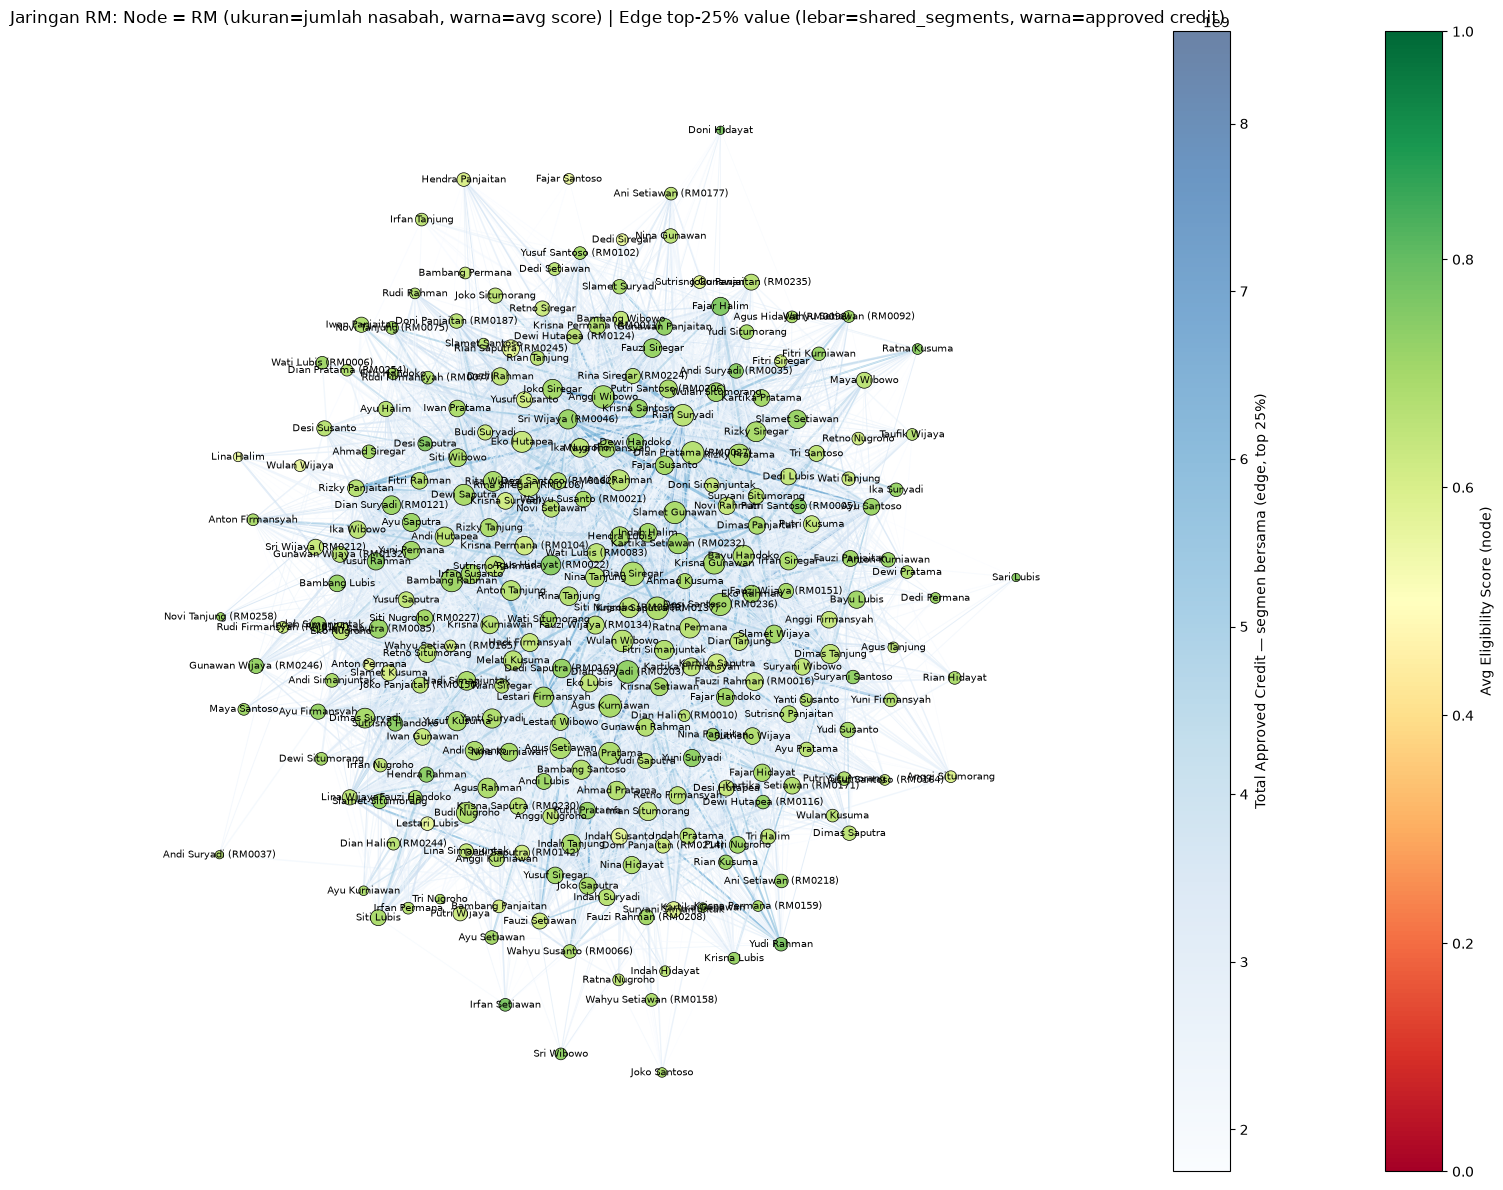

In [10]:
fig, ax = plt.subplots(figsize=(15, 12))

pos = nx.spring_layout(G, seed=42, k=0.9, weight="jaccard")

node_sizes = [rm_nodes.set_index(COL["rm_id"]).loc[n, "n_nasabah"] * 12 for n in G.nodes]
node_colors = [rm_nodes.set_index(COL["rm_id"]).loc[n, "avg_eligibility_score"] for n in G.nodes]

credit_threshold = edges_df["total_approved_credit_shared"].quantile(0.75)
edges_to_draw = [(u, v) for u, v, d in G.edges(data=True)
                 if d["total_approved_credit_shared"] >= credit_threshold]
edge_widths = [G[u][v]["shared_segments"] * 0.35 for u, v in edges_to_draw]
edge_colors = [G[u][v]["total_approved_credit_shared"] for u, v in edges_to_draw]

nodes_drawn = nx.draw_networkx_nodes(
    G, pos, node_size=node_sizes, node_color=node_colors,
    cmap=cm.RdYlGn, vmin=0, vmax=1, ax=ax, edgecolors="black", linewidths=0.5,
)
edges_drawn = nx.draw_networkx_edges(
    G, pos, edgelist=edges_to_draw, width=edge_widths, edge_color=edge_colors,
    edge_cmap=cm.Blues, alpha=0.6, ax=ax,
)
nx.draw_networkx_labels(
    G, pos,
    labels={n: rm_nodes.set_index(COL["rm_id"]).loc[n, "rm_label"] for n in G.nodes},
    font_size=7, ax=ax,
)

cbar1 = plt.colorbar(nodes_drawn, ax=ax, label="Avg Eligibility Score (node)", pad=0.02)
cbar2 = plt.colorbar(edges_drawn, ax=ax, label="Total Approved Credit — segmen bersama (edge, top 25%)", pad=0.06)
ax.set_title("Jaringan RM: Node = RM (ukuran=jumlah nasabah, warna=avg score) | "
             f"Edge top-25% value (lebar=shared_segments, warna=approved credit)")
ax.axis("off")
plt.tight_layout()
plt.show()

### Tahap 7b — Fokus per Cluster (Louvain)

Warna node = cluster hasil Louvain, biar terlihat kelompok RM dengan portofolio paling mirip.

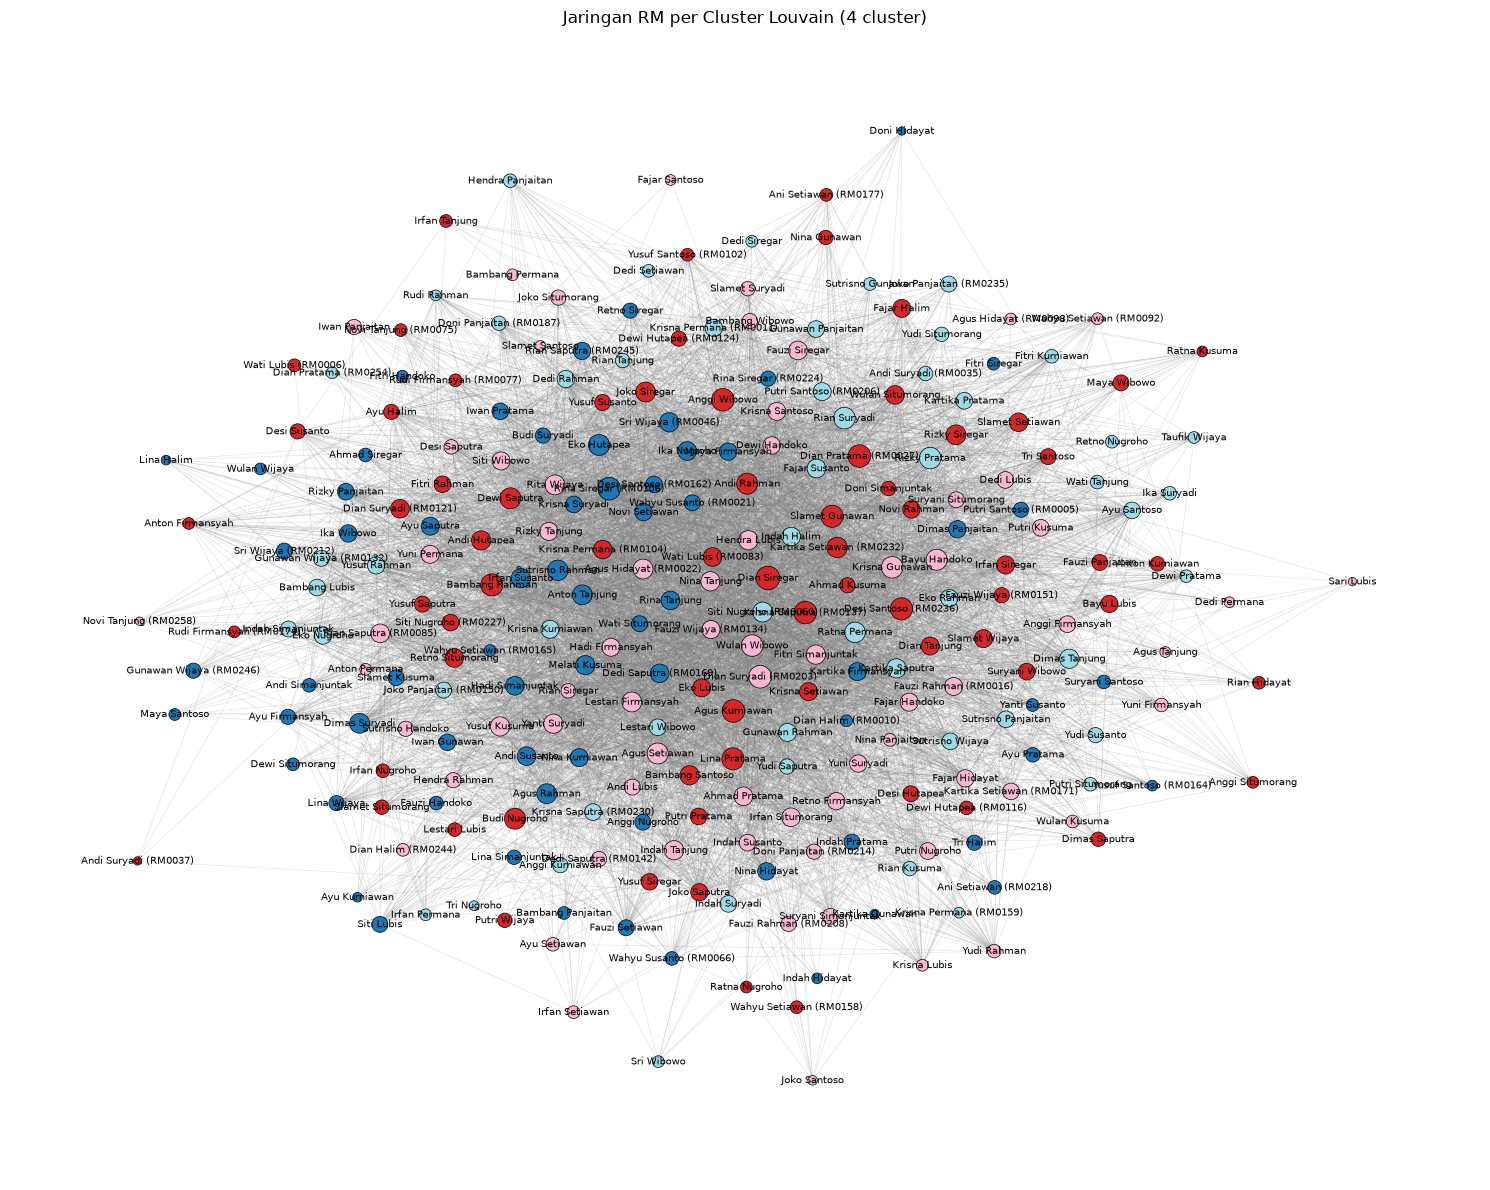

In [11]:
fig, ax = plt.subplots(figsize=(15, 12))

cluster_map = rm_nodes.set_index(COL["rm_id"])["cluster_id"].to_dict()
node_cluster_colors = [cluster_map.get(n, -1) for n in G.nodes]

nodes_drawn = nx.draw_networkx_nodes(
    G, pos, node_size=node_sizes, node_color=node_cluster_colors,
    cmap=cm.tab20, ax=ax, edgecolors="black", linewidths=0.5,
)
nx.draw_networkx_edges(G, pos, edgelist=edges_to_draw, width=0.4, alpha=0.25, edge_color="gray", ax=ax)
nx.draw_networkx_labels(
    G, pos,
    labels={n: rm_nodes.set_index(COL["rm_id"]).loc[n, "rm_label"] for n in G.nodes},
    font_size=7, ax=ax,
)
ax.set_title(f"Jaringan RM per Cluster Louvain ({len(communities)} cluster)")
ax.axis("off")
plt.tight_layout()
plt.show()

## Tahap 8 — Insight Otomatis & Export

Auto-generate narasi dari:
- Pasangan RM dengan **irisan segmen + value kredit terbesar** (kandidat cross-referral / concentration risk).
- Pasangan RM di segmen sama tapi **gap eligibility_score besar** (indikasi inkonsistensi scoring antar RM).
- Cluster RM dengan **total approved credit terbesar** (konsentrasi eksposur per kelompok segmen).

Lalu node & edge table di-export ke `data/processed/` supaya bisa dipakai ulang (mis. di Gephi atau Streamlit dashboard).

In [12]:
insights = []

insights.append(
    f"- Rata-rata portofolio RM mencakup {div_check['n_industry'].mean():.1f}/{n_industry_total} "
    f"industry ({avg_industry_cov:.0%}) dan {div_check['n_region'].mean():.1f}/{n_region_total} region "
    f"({avg_region_cov:.0%}) berbeda — densitas graph RM-RM saat ini {nx.density(G):.2f}. "
    + ("Portofolio RM terdiversifikasi merata, bukan tersegmentasi ketat per industry/region."
       if avg_industry_cov > 0.7 and avg_region_cov > 0.7
       else "Ada indikasi spesialisasi RM ke industry/region tertentu.")
)

top_pairs = edges_df.sort_values("total_approved_credit_shared", ascending=False).head(3)
name_map = rm_nodes.set_index(COL["rm_id"])["rm_label"].to_dict()
region_map = rm_nodes.set_index(COL["rm_id"])["region"].to_dict()

for _, r in top_pairs.iterrows():
    a, b = r["rm_id_a"], r["rm_id_b"]
    insights.append(
        f"- RM {name_map.get(a, a)} ({region_map.get(a)}) & RM {name_map.get(b, b)} ({region_map.get(b)}) "
        f"beririsan di {int(r['shared_segments'])} segmen industry/sub_industry/region yang sama, dengan total "
        f"nominal kredit disetujui gabungan Rp {r['total_approved_credit_shared']:,.0f} dan rata-rata "
        f"eligibility_score {r['avg_eligibility_score_shared']:.2f} — kandidat concentration risk / peluang "
        f"cross-referral segmen."
    )

edges_df["score_gap"] = (
    edges_df["rm_id_a"].map(rm_nodes.set_index(COL["rm_id"])["avg_eligibility_score"])
    - edges_df["rm_id_b"].map(rm_nodes.set_index(COL["rm_id"])["avg_eligibility_score"])
).abs()
top_gap = edges_df[edges_df["n_customers_shared"] >= 10].sort_values("score_gap", ascending=False).head(3)
for _, r in top_gap.iterrows():
    a, b = r["rm_id_a"], r["rm_id_b"]
    insights.append(
        f"- RM {name_map.get(a, a)} & RM {name_map.get(b, b)} menggarap segmen yang sama (irisan "
        f"{int(r['n_customers_shared'])} nasabah) tapi rata-rata eligibility_score portofolio mereka "
        f"berbeda {r['score_gap']:.2f} poin — indikasi perlu review konsistensi kriteria scoring antar RM."
    )

top_cluster = cluster_summary.head(2)
for cid, row in top_cluster.iterrows():
    insights.append(
        f"- Cluster RM #{cid} berisi {int(row['n_rm'])} RM di region dominan {row['dominant_region']} / "
        f"sub_industry dominan {row['dominant_sub_industry']}, menggarap total {int(row['total_nasabah'])} "
        f"nasabah dengan total approved credit Rp {row['total_approved_credit']:,.0f} — konsentrasi eksposur "
        f"kredit terbesar di jaringan RM."
    )

print("\n".join(insights))

- Rata-rata portofolio RM mencakup 5.0/6 industry (83%) dan 3.7/4 region (92%) berbeda — densitas graph RM-RM saat ini 0.77. Portofolio RM terdiversifikasi merata, bukan tersegmentasi ketat per industry/region.
- RM Dedi Saputra (RM0169) (Kantor Wilayah Jakarta BSD) & RM Dian Siregar (Kantor Wilayah Jakarta Kemayoran) beririsan di 8 segmen industry/sub_industry/region yang sama, dengan total nominal kredit disetujui gabungan Rp 8,550,000,000 dan rata-rata eligibility_score 0.71 — kandidat concentration risk / peluang cross-referral segmen.
- RM Dian Suryadi (RM0203) (Kantor Wilayah 15 (Jakarta Timur)) & RM Hendra Lubis (Kantor Wilayah 15 (Jakarta Timur)) beririsan di 6 segmen industry/sub_industry/region yang sama, dengan total nominal kredit disetujui gabungan Rp 7,550,000,000 dan rata-rata eligibility_score 0.71 — kandidat concentration risk / peluang cross-referral segmen.
- RM Dedi Saputra (RM0169) (Kantor Wilayah Jakarta BSD) & RM Rian Suryadi (Kantor Wilayah Jakarta BSD) beririsa

In [13]:
import os

OUT_DIR = "../data/processed"
os.makedirs(OUT_DIR, exist_ok=True)

rm_nodes.to_csv(os.path.join(OUT_DIR, "rm_network_nodes.csv"), index=False)
edges_df.to_csv(os.path.join(OUT_DIR, "rm_network_edges.csv"), index=False)

print("Tersimpan:")
print(" -", os.path.join(OUT_DIR, "rm_network_nodes.csv"), rm_nodes.shape)
print(" -", os.path.join(OUT_DIR, "rm_network_edges.csv"), edges_df.shape)

Tersimpan:
 - ../data/processed\rm_network_nodes.csv (261, 25)
 - ../data/processed\rm_network_edges.csv (26014, 11)


## Penutup & Next Steps

- Graph ini bisa langsung dipakai untuk slide **"RM Network: Segment Overlap & Credit Concentration"** —
  hasil Tahap 8 sudah dalam bentuk bullet point siap tempel.
- `rm_network_nodes.csv` & `rm_network_edges.csv` bisa diimpor ke Gephi untuk eksplorasi visual lebih interaktif,
  atau disambungkan ke tab baru di Streamlit dashboard (`app_premium.py` / `pages_v2/`).
- Value edge saat ini dihitung dari **irisan segmen komposit** (industry|sub_industry|region persis sama).
  Kalau butuh definisi lebih longgar (mis. RM dianggap terhubung kalau *region saja* sama, tanpa perlu
  industry/sub_industry sama), tinggal ganti definisi `segment` di Tahap 1 jadi kolom tunggal (`region` saja)
  dan re-run dari Tahap 3.
- **Temuan Tahap 1b**: kalau portofolio RM ternyata terdiversifikasi merata (bukan fokus per
  industry/region), artinya assignment `rm_id` ke nasabah di data generator saat ini kemungkinan besar
  random/round-robin, bukan berdasarkan spesialisasi geografis/sektor RM. Kalau use case sebenarnya butuh
  graph yang merefleksikan **struktur organisasi RM** (siapa satu cabang dengan siapa), pakai `branch_name`/
  `region` dari `rm_master.csv` langsung sebagai kriteria edge (bukan hasil agregasi dari portofolio
  nasabah) — itu akan menghasilkan cluster yang tegas sesuai struktur cabang.
- Untuk memperkuat use case **RM collusion/fraud risk**, bisa ditambah sinyal lain di edge value: kesamaan
  agunan (`collateral_location`), kesamaan alamat, atau pola approval rate yang mencurigakan (RM dengan
  approval rate jauh di atas rata-rata cluster-nya).